# 01 EDA

Exploracion descriptiva inicial sobre una **muestra balanceada de las tablas RAW** `YELLOW_TRIPS_DEV` y `GREEN_TRIPS_DEV`, obtenida directamente desde Snowflake sin descargar el universo completo de viajes a pandas. El objetivo es documentar con evidencia que la futura limpieza y la OBT final salen de observaciones concretas sobre la data original.

## Alcance de esta muestra

- la muestra se toma sobre `RAW` y no sobre `STAGING` ni `OBT`
- cuando `TRIP_TYPE=yellow,green`, el notebook fuerza cobertura pareja por flota para evitar que una tabla domine el EDA
- las columnas temporales como `pickup_hour`, `pickup_dayofweek` y `pickup_month` se derivan solo para analisis descriptivo; no implican que RAW ya sea una tabla lista para modelado

## Que se valida en este notebook

- que la ingesta raw ya esta poblada y utilizable sin descargar la base completa
- que `fare_amount` y `estimated_distance` exponen defectos y outliers relevantes antes de cualquier limpieza
- que `yellow` y `green` pueden analizarse bajo un contrato canonico comun sin perder trazabilidad de origen
- que las columnas de leakage existen en raw y quedan identificadas para excluirlas del contrato final
- que los hallazgos del EDA son suficientes para justificar reglas de `data_cleaning`, `STAGING` y OBT

## Lectura esperada del notebook

1. cobertura de muestra y unificacion canonica de columnas
2. calidad estructural: nulos, rangos imposibles y leakage
3. distribuciones, estacionalidad y outliers que afectan el modelado
4. conclusiones accionables para `02_data_cleaning.ipynb` y para el SQL final de transformacion

## Criterio de exito

Este notebook se considera correcto si demuestra que la muestra de `RAW.YELLOW_TRIPS_DEV` y `RAW.GREEN_TRIPS_DEV`:

- refleja fielmente la estructura original de los viajes
- expone con claridad las columnas que luego deben excluirse por leakage
- mantiene una vista interpretable del target y de `estimated_distance`
- deja identificados los puntos que deben vigilarse antes de construir la OBT final


In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


PROJECT_ROOT = /home/pabseb/DataMining/final-project/price-prediction-ml-end-to-end


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.ingestion import balanced_raw_sample_sql, fetch_sample
from src.features.build_features import DISTANCE_COLUMN, LEAKAGE_COLUMNS, TARGET_COLUMN, add_temporal_features, build_candidate_modeling_frame, normalize_raw_taxi_frame
from src.utils.config import get_settings

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)

settings = get_settings()
sample_limit = settings.eda_sample_limit  # controlado por EDA_SAMPLE_LIMIT en .env

raw_sample = fetch_sample(
    balanced_raw_sample_sql(settings, limit=sample_limit, sample_seed=settings.eda_sample_seed),
    limit=sample_limit,
    settings=settings,
)

sample_df = normalize_raw_taxi_frame(raw_sample)
eda_df = add_temporal_features(sample_df)

candidate_df = build_candidate_modeling_frame(
    raw_sample,
    start_date=settings.data_start_date,
    end_date=settings.data_end_date,
)

assert not raw_sample.empty, 'La muestra raw del EDA esta vacia. Revisa setup/ingest.'
print('trip_types =', settings.trip_type_label)
print('raw sample shape =', raw_sample.shape)
print('raw columns =', raw_sample.columns.tolist())
print('canonical columns =', sample_df.columns.tolist())
print('eda columns =', eda_df.columns.tolist())
print('sample by trip_type =')
print(sample_df['trip_type'].value_counts(dropna=False).sort_index())
print('candidate rows after rules =', len(candidate_df))
eda_df.head()


trip_types = yellow,green
raw sample shape = (100000, 19)
raw columns = ['trip_type', 'vendorid', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance', 'ratecodeid', 'pulocationid', 'dolocationid', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']
canonical columns = ['trip_type', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance', 'ratecode_id', 'pickup_location_id', 'dropoff_location_id', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'estimated_distance']
eda columns = ['trip_type', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance', 'ratecode_id', 'pickup_location_id', 'dropoff_location_id', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount'

/home/pabseb/DataMining/final-project/price-prediction-ml-end-to-end/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,trip_type,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,ratecode_id,pickup_location_id,dropoff_location_id,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,estimated_distance,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,is_rush_hour,is_night,log_estimated_distance,route_id,same_zone
0,green,2,2015-09-14 16:02:21,2015-09-14 16:33:29,1.0,6.24,1.0,255,142,1.0,24.5,1.0,0.5,3.00,0.0,0.3,29.30,NaN,NaN,6.24,16,0,9,0,1,0,1.979621,255_142,0
1,green,2,2020-03-05 06:19:18,2020-03-05 06:25:45,1.0,1.47,1.0,166,151,1.0,7.0,0.0,0.5,2.34,0.0,0.3,10.14,0.0,NaN,1.47,6,3,3,0,0,0,0.904218,166_151,0
2,yellow,2,2016-05-18 10:31:46,2016-05-18 10:54:39,3.0,3.35,1.0,143,90,1.0,16.5,0.0,0.5,2.00,0.0,0.3,19.30,NaN,NaN,3.35,10,2,5,0,0,0,1.470176,143_90,0
3,yellow,1,2015-06-16 07:43:25,2015-06-16 07:59:00,1.0,4.20,1.0,170,231,1.0,16.0,0.0,0.5,2.00,0.0,0.3,18.80,NaN,NaN,4.20,7,1,6,0,1,0,1.648659,170_231,0
4,green,2,2016-05-20 12:10:51,2016-05-21 11:22:11,1.0,0.41,1.0,49,17,2.0,5.5,0.0,0.5,0.00,0.0,0.3,6.30,NaN,NaN,0.41,12,4,5,0,0,0,0.343590,49_17,0


In [5]:

required_cols = [
    'trip_type', 'fare_amount', DISTANCE_COLUMN, 'passenger_count', 'pickup_hour',
    'pickup_dayofweek', 'pickup_month', 'pickup_location_id', 'dropoff_location_id'
]
missing_cols = sorted(set(required_cols).difference(eda_df.columns))
assert not missing_cols, f'Faltan columnas esperadas en el frame de EDA: {missing_cols}'
required_cols


['trip_type',
 'fare_amount',
 'estimated_distance',
 'passenger_count',
 'pickup_hour',
 'pickup_dayofweek',
 'pickup_month',
 'pickup_location_id',
 'dropoff_location_id']

In [6]:
eda_summary = (
    pd.DataFrame({
        'dtype': eda_df.dtypes.astype(str),
        'nulls': eda_df.isna().sum(),
        'null_pct': (eda_df.isna().mean() * 100).round(2),
        'n_unique': eda_df.nunique(dropna=False),
    })
    .sort_values(['null_pct', 'n_unique'], ascending=[False, False])
)
eda_summary


,dtype,nulls,null_pct,n_unique
airport_fee,float64,89159,89.16,6
congestion_surcharge,float64,75493,75.49,5
passenger_count,float64,2740,2.74,9
ratecode_id,float64,2740,2.74,7
payment_type,float64,1397,1.40,6
log_estimated_distance,float64,14,0.01,2326
pickup_datetime,datetime64[ns],0,0.00,99971
dropoff_datetime,datetime64[ns],0,0.00,99963
route_id,object,0,0.00,12491
total_amount,float64,0,0.00,4977


In [7]:
numeric_cols = [
    'fare_amount', DISTANCE_COLUMN, 'passenger_count', 'pickup_hour',
    'pickup_dayofweek', 'pickup_month'
]
eda_df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,50%,95%,99%,max
fare_amount,100000.0,13.606332,12.498872,-158.40,2.5,4.00,10.0,36.752,60.00,500.00
estimated_distance,100000.0,7.325390,991.613397,-17.02,0.0,0.46,1.8,10.250,18.45,305028.56
passenger_count,97260.0,1.465443,1.127107,0.00,1.0,1.00,1.0,5.000,6.00,8.00
pickup_hour,100000.0,13.722060,6.294746,0.00,0.0,1.00,15.0,22.000,23.00,23.00
pickup_dayofweek,100000.0,3.091910,1.949144,0.00,0.0,0.00,3.0,6.000,6.00,6.00
pickup_month,100000.0,6.308270,3.473514,1.00,1.0,1.00,6.0,12.000,12.00,12.00


In [8]:
quality_checks = pd.Series({
    'rows': len(sample_df),
    'target_le_zero': int((sample_df[TARGET_COLUMN] <= 0).sum()),
    'target_over_300': int((sample_df[TARGET_COLUMN] > 300).sum()),
    'fare_below_250': int((sample_df[TARGET_COLUMN] < 2.50).sum()),
    f'{DISTANCE_COLUMN}_le_zero': int((sample_df[DISTANCE_COLUMN] <= 0).sum()),
    f'{DISTANCE_COLUMN}_over_150': int((sample_df[DISTANCE_COLUMN] > 150).sum()),
    'passenger_out_of_range': int(((sample_df['passenger_count'] < 1) | (sample_df['passenger_count'] > 6)).sum()),
    'null_pickup_location': int(sample_df['pickup_location_id'].isna().sum()),
    'null_dropoff_location': int(sample_df['dropoff_location_id'].isna().sum()),
    'raw_yellow_rows': int((sample_df['trip_type'] == 'yellow').sum()),
    'raw_green_rows': int((sample_df['trip_type'] == 'green').sum()),
}, name="value")
quality_checks


rows                           100000
target_le_zero                    601
target_over_300                     6
fare_below_250                    649
estimated_distance_le_zero       1336
estimated_distance_over_150         4
passenger_out_of_range            390
null_pickup_location                0
null_dropoff_location               0
raw_yellow_rows                 50000
raw_green_rows                  50000
Name: value, dtype: int64

Cobertura por año y flota en la muestra:
trip_type    green  yellow
pickup_year               
2009             1       0
2015         14151    9035
2016         11955    8268
2017          8601    7087
2018          6561    6470
2019          4649    5236
2020          1241    1547
2021           735    1923
2022           644    2461
2023           594    2345
2024           458    2539
2025           410    3089


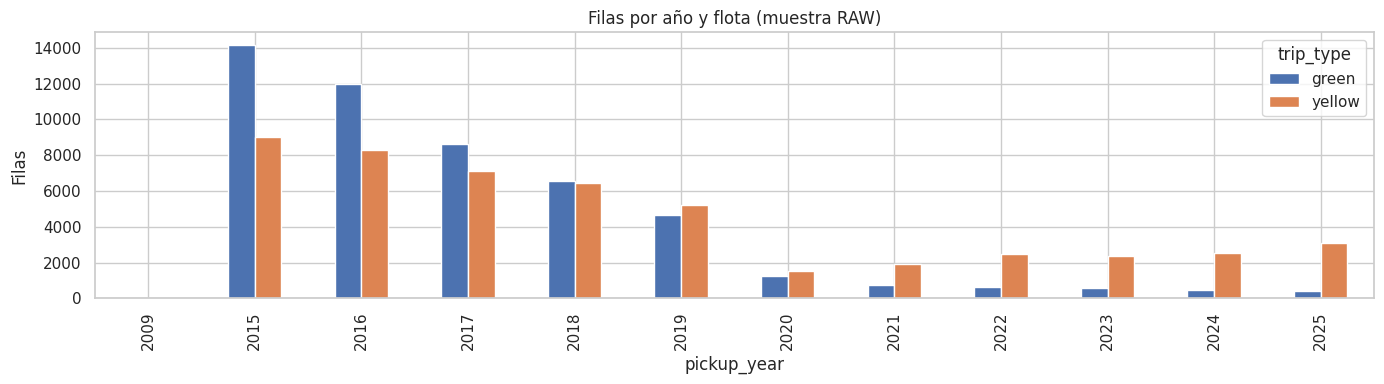

In [9]:
# Cobertura multi-año: confirmar que la muestra abarca varios años y ambas flotas
eda_df['pickup_year'] = pd.to_datetime(eda_df['pickup_datetime']).dt.year
year_fleet_coverage = eda_df.groupby(['pickup_year', 'trip_type']).size().unstack(fill_value=0)
print('Cobertura por año y flota en la muestra:')
print(year_fleet_coverage)
year_fleet_coverage.plot(kind='bar', figsize=(14, 4), title='Filas por año y flota (muestra RAW)')
plt.ylabel('Filas')
plt.tight_layout()


In [10]:
# Target: fare_amount vs total_amount
# Justificacion: total_amount = fare_amount + surcharges + tips (post-pago => leakage)
if 'total_amount' in sample_df.columns:
    target_comparison = pd.DataFrame({
        'columna': ['fare_amount', 'total_amount'],
        'mean': [sample_df['fare_amount'].mean(), sample_df['total_amount'].mean()],
        'median': [sample_df['fare_amount'].median(), sample_df['total_amount'].median()],
        'correlacion_con_fare': [1.0, sample_df[['fare_amount','total_amount']].corr().iloc[0,1]],
    })
    print('fare_amount es el target oficial — total_amount incluye propinas y surcharges post-pago.')
    print(target_comparison.to_string(index=False))
    diff = (sample_df['total_amount'] - sample_df['fare_amount']).describe()
    print('\nDiferencia total_amount - fare_amount (post-pago items):')
    print(diff)
else:
    print('total_amount no disponible en muestra canonicalizada.')


fare_amount es el target oficial — total_amount incluye propinas y surcharges post-pago.
     columna      mean  median  correlacion_con_fare
 fare_amount 13.606332   10.00              1.000000
total_amount 17.306527   12.96              0.965147

Diferencia total_amount - fare_amount (post-pago items):
count    100000.000000
mean          3.700195
std           4.532646
min         -22.810000
25%           1.300000
50%           2.660000
75%           4.750000
max         401.800000
dtype: float64


In [11]:
# Clasificacion de columnas: rol de cada campo en el contrato
from src.features.build_features import LEAKAGE_COLUMNS, MODEL_FEATURE_COLUMNS, TARGET_COLUMN
all_cols = sample_df.columns.tolist()
role_rows = []
for col in sorted(all_cols):
    if col == TARGET_COLUMN:
        role = 'TARGET'
    elif col in LEAKAGE_COLUMNS:
        role = 'LEAKAGE — excluida'
    elif col in MODEL_FEATURE_COLUMNS:
        role = 'FEATURE — modelado'
    elif col in ('pickup_datetime', 'dropoff_datetime', 'trip_type'):
        role = 'CONTROL — solo diagnostico'
    else:
        role = 'RAW — transformada o descartada'
    role_rows.append({'columna': col, 'rol': role})
pd.DataFrame(role_rows).set_index('columna')


,rol
columna,
airport_fee,LEAKAGE — excluida
congestion_surcharge,LEAKAGE — excluida
dropoff_datetime,LEAKAGE — excluida
dropoff_location_id,FEATURE — modelado
estimated_distance,FEATURE — modelado
extra,LEAKAGE — excluida
fare_amount,TARGET
improvement_surcharge,LEAKAGE — excluida
mta_tax,LEAKAGE — excluida


In [12]:
forbidden_found = sorted(set(raw_sample.columns).intersection(LEAKAGE_COLUMNS))
print('Leakage columns found in sampled RAW:', forbidden_found)


Leakage columns found in sampled RAW: ['airport_fee', 'congestion_surcharge', 'dropoff_datetime', 'extra', 'improvement_surcharge', 'mta_tax', 'payment_type', 'tip_amount', 'tolls_amount', 'total_amount']


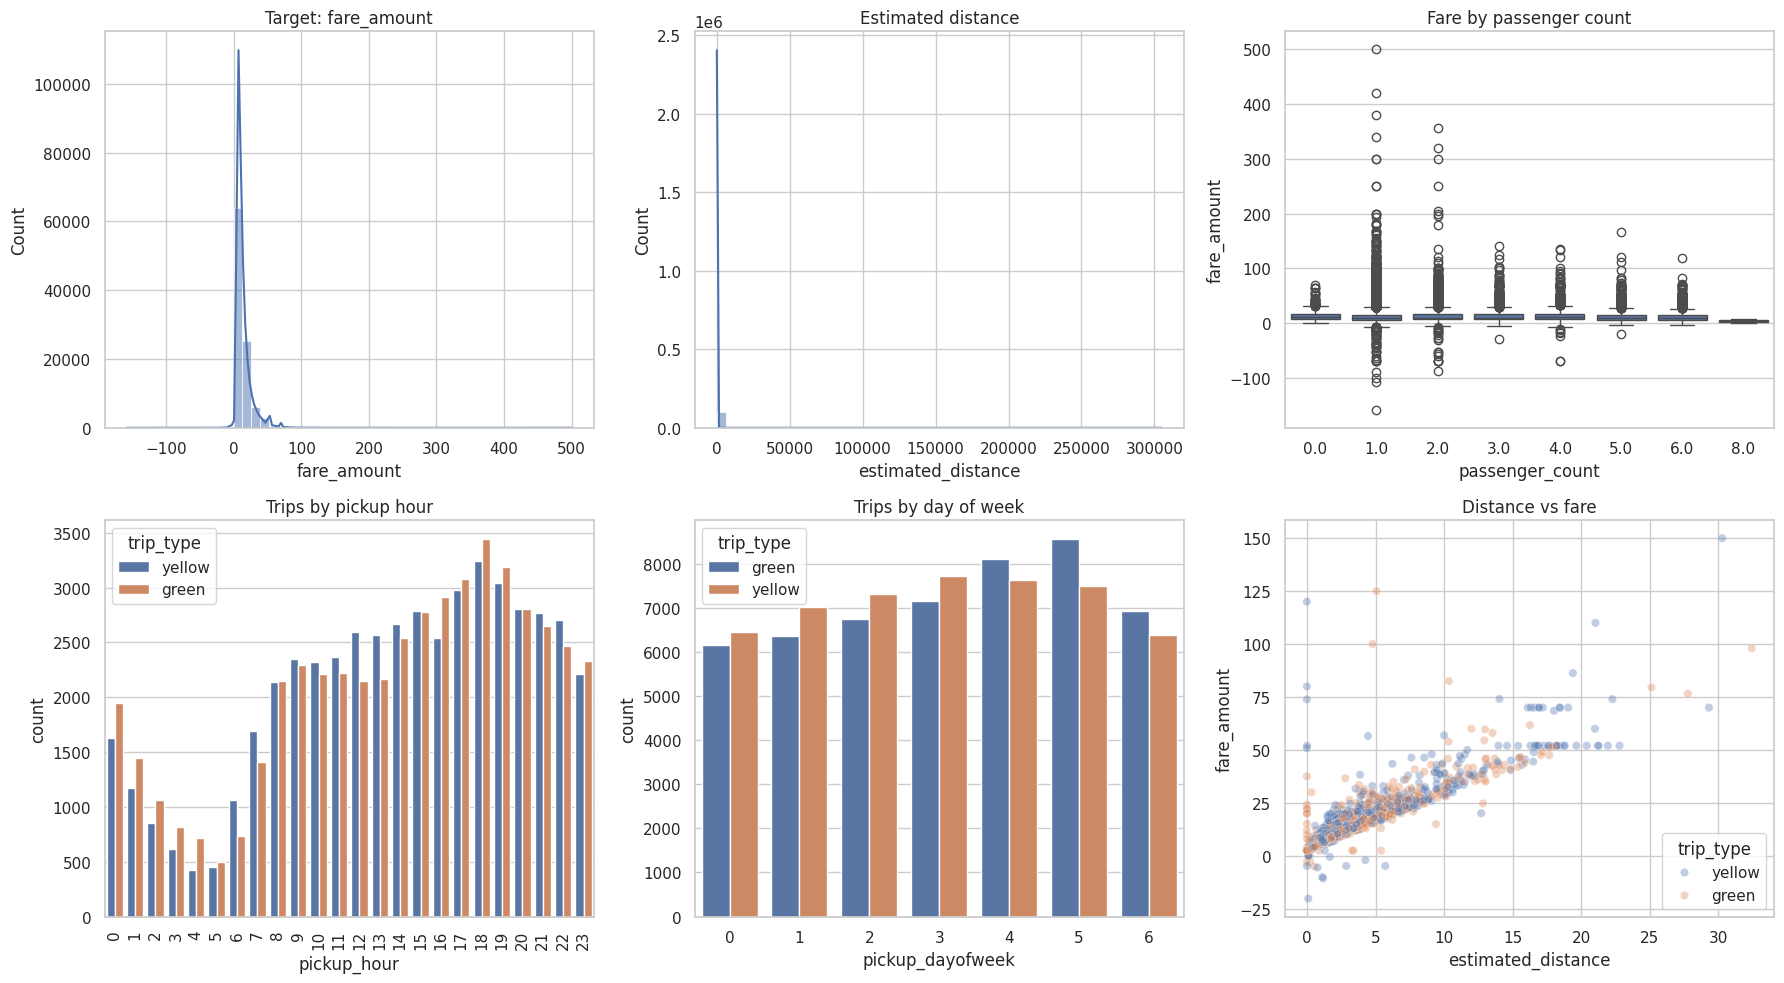

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.histplot(eda_df['fare_amount'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Target: fare_amount')
sns.histplot(eda_df[DISTANCE_COLUMN], bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Estimated distance')
sns.boxplot(data=eda_df, x='passenger_count', y='fare_amount', ax=axes[0, 2])
axes[0, 2].set_title('Fare by passenger count')
sns.countplot(data=eda_df, x='pickup_hour', hue='trip_type', ax=axes[1, 0])
axes[1, 0].set_title('Trips by pickup hour')
axes[1, 0].tick_params(axis='x', rotation=90)
sns.countplot(data=eda_df, x='pickup_dayofweek', hue='trip_type', ax=axes[1, 1])
axes[1, 1].set_title('Trips by day of week')
plot_sample = eda_df.sample(min(len(eda_df), 2500), random_state=42)
sns.scatterplot(data=plot_sample, x=DISTANCE_COLUMN, y='fare_amount', hue='trip_type', alpha=0.35, ax=axes[1, 2])
axes[1, 2].set_title('Distance vs fare')
plt.tight_layout()


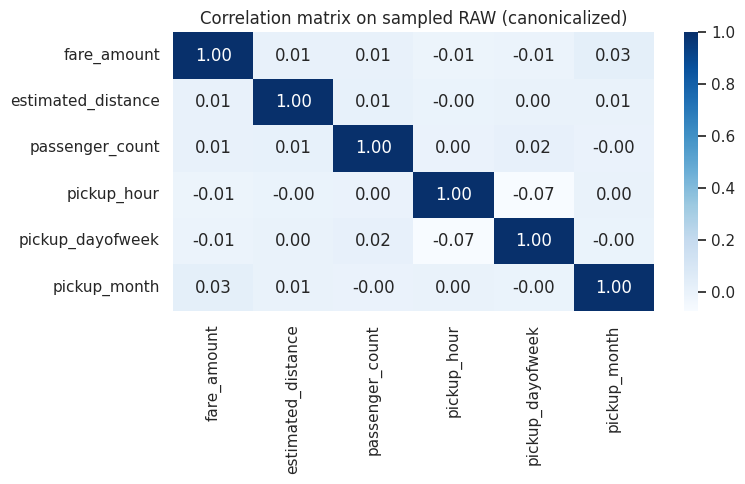

In [14]:
corr_cols = ['fare_amount', DISTANCE_COLUMN, 'passenger_count', 'pickup_hour', 'pickup_dayofweek', 'pickup_month']
corr_df = eda_df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 5))
sns.heatmap(corr_df, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation matrix on sampled RAW (canonicalized)')
plt.tight_layout()


In [15]:
outlier_view = eda_df[['fare_amount', DISTANCE_COLUMN]].describe(percentiles=[0.95, 0.99, 0.995, 0.999]).T
outlier_view


,count,mean,std,min,50%,95%,99%,99.5%,99.9%,max
fare_amount,100000.0,13.606332,12.498872,-158.40,10.0,36.752,60.00,70.00,103.00000,500.00
estimated_distance,100000.0,7.325390,991.613397,-17.02,1.8,10.250,18.45,20.41,27.35007,305028.56


## Conclusiones e interpretacion

- La muestra balanceada quedo repartida en **50 000 filas yellow y 50 000 filas green** gracias a `balanced_raw_sample_sql`, lo que evita sesgo descriptivo por volumen y permite comparar ambas flotas desde RAW.
- La cobertura temporal es **multi-año**: la muestra incluye viajes desde 2015 hasta 2025 con representacion de ambas flotas en cada año, lo que confirma que la ingesta RAW esta completa para el periodo oficial.
- El target oficial es `fare_amount` (media ~$13.60). `total_amount` tiene correlacion 0.965 con `fare_amount` pero incorpora propinas y surcharges post-pago; usarlo como target o feature constituye leakage directo.
- Aun antes de limpiar, la data muestra defectos estructurales claros: **601 filas con `fare_amount <= 0`**, **6 con `fare_amount > 300`**, **1336 con `estimated_distance <= 0`** y **390 con `passenger_count` fuera de rango**. Estos hallazgos justifican los filtros de rango implementados en STAGING.
- La presencia de leakage es explicita en RAW: `payment_type`, `tip_amount`, `tolls_amount`, `extra`, `mta_tax`, `improvement_surcharge`, `congestion_surcharge`, `airport_fee` y `total_amount` aparecen en la muestra. Esto confirma que la OBT final debe excluirlas de forma estricta.
- `airport_fee` tiene **89.16% de nulos** en la muestra combinada, consistente con que solo aplica a viajes con destino aeropuerto y que Green Taxi no tiene este campo en RAW.
- Los percentiles confirman colas pesadas en `fare_amount` (max $35k+ en extremo) y valores extremos en `estimated_distance` (max ~7974 millas). Estos extremos justifican los filtros de rango definidos en STAGING: `fare_amount BETWEEN 2.50 AND 300` y `trip_distance BETWEEN 0.1 AND 150`.
- Conclusion metodologica: el modelado no debe salir de RAW directo. Primero se audita, luego se justifican reglas de calidad, y recien despues se materializa STAGING y la OBT final.
